In [2]:
# Imort necessary libraries
import pandas as pd

# Reading in the data
bills_actions = pd.read_csv("C:\\Users\\jland\\OneDrive\\Emory Essentials\\CLASSES Fall 2025\\Computing\\datasci530fall2025\\Lecture 10\\data_raw\\bills_actions.csv")
bills_actions.dtypes
bills_actions.duplicated().sum()  

# there are 3,303 rows and 7 columns, 49 of these rows are duplicates

bills_actions['bill_number'].is_unique # not an individual identifier
bills_actions['member_id'].is_unique # also not a unique identifier
bills_actions

,Congress,bill_number,bill_type,action,main_action,category,member_id
0,116,1029,s,S.Amdt.1274 Amendment SA 1274 proposed by Sena...,senate amendment proposed (on the floor),amendment,858
1,116,1031,s,S.Amdt.2698 Amendment SA 2698 proposed by Sena...,senate amendment proposed (on the floor),amendment,675
2,116,1160,s,S.Amdt.2659 Amendment SA 2659 proposed by Sena...,senate amendment proposed (on the floor),amendment,858
3,116,1199,s,"Committee on Health, Education, Labor, and Pen...",senate committee/subcommittee actions,senate bill,1561
4,116,1208,s,Committee on the Judiciary. Reported by Senato...,senate committee/subcommittee actions,senate bill,1580
...,...,...,...,...,...,...,...
3298,116,9,hr,H.Amdt.172 Amendment (A004) offered by Ms. Kus...,house amendment offered,amendment,36
3299,116,9,hr,H.Amdt.171 Amendment (A003) offered by Ms. Hou...,house amendment offered,amendment,186
3300,116,9,hr,H.Amdt.170 Amendment (A002) offered by Ms. Oma...,house amendment offered,amendment,477
3301,116,9,hr,POSTPONED PROCEEDINGS - At the conclusion of d...,other house amendment actions,amendment,393


In [3]:
# Checking for potential unique identifiers

candidates = [
    ["bill_number", "bill_type", "action"],
    ["bill_number", "bill_type", "member_id", "action"],
    ["bill_number", "bill_type", "main_action", "member_id"],
    ["bill_number", "bill_type", "main_action", "action"],
]

for cols in candidates:
    dups = bills_actions.duplicated(subset=cols).sum()
    print(cols, "duplicates:", dups, "→ unique?" , dups == 0)

['bill_number', 'bill_type', 'action'] duplicates: 49 → unique? False
['bill_number', 'bill_type', 'member_id', 'action'] duplicates: 49 → unique? False
['bill_number', 'bill_type', 'main_action', 'member_id'] duplicates: 529 → unique? False
['bill_number', 'bill_type', 'main_action', 'action'] duplicates: 49 → unique? False


In [4]:
## After looking through the data, I don't see a reason to keep the duplicates, so I will remove them.
# counts how many times each combination of all columns occurs
bills_actions["dups"] = bills_actions.duplicated(keep=False)  # True/False if row appears >1

bills_actions = bills_actions[bills_actions["dups"] == 0]

bills_actions.duplicated().sum()   ## now we have no duplicates
bills_actions.dtypes



Congress        int64
bill_number     int64
bill_type      object
action         object
main_action    object
category       object
member_id       int64
dups             bool
dtype: object

In [5]:
for col in bills_actions.columns:
    print(col, bills_actions[col].nunique())
bills_actions 
    ## 
    ## There are no unique identifiers in this dataset
    ## There 1,331 unique bill numbers, 8 different bill types, 9 different categories

Congress 1
bill_number 1331
bill_type 8
action 2404
main_action 13
category 9
member_id 381
dups 1


,Congress,bill_number,bill_type,action,main_action,category,member_id,dups
0,116,1029,s,S.Amdt.1274 Amendment SA 1274 proposed by Sena...,senate amendment proposed (on the floor),amendment,858,False
1,116,1031,s,S.Amdt.2698 Amendment SA 2698 proposed by Sena...,senate amendment proposed (on the floor),amendment,675,False
2,116,1160,s,S.Amdt.2659 Amendment SA 2659 proposed by Sena...,senate amendment proposed (on the floor),amendment,858,False
3,116,1199,s,"Committee on Health, Education, Labor, and Pen...",senate committee/subcommittee actions,senate bill,1561,False
4,116,1208,s,Committee on the Judiciary. Reported by Senato...,senate committee/subcommittee actions,senate bill,1580,False
...,...,...,...,...,...,...,...,...
3298,116,9,hr,H.Amdt.172 Amendment (A004) offered by Ms. Kus...,house amendment offered,amendment,36,False
3299,116,9,hr,H.Amdt.171 Amendment (A003) offered by Ms. Hou...,house amendment offered,amendment,186,False
3300,116,9,hr,H.Amdt.170 Amendment (A002) offered by Ms. Oma...,house amendment offered,amendment,477,False
3301,116,9,hr,POSTPONED PROCEEDINGS - At the conclusion of d...,other house amendment actions,amendment,393,False


category
amendment                       0.456157
house bill                      0.272699
senate bill                     0.159826
house resolution                0.072761
senate resolution               0.018657
house joint resolution          0.006841
house concurrent resolution     0.006219
senate concurrent resolution    0.004353
senate joint resolution         0.002488
dtype: float64


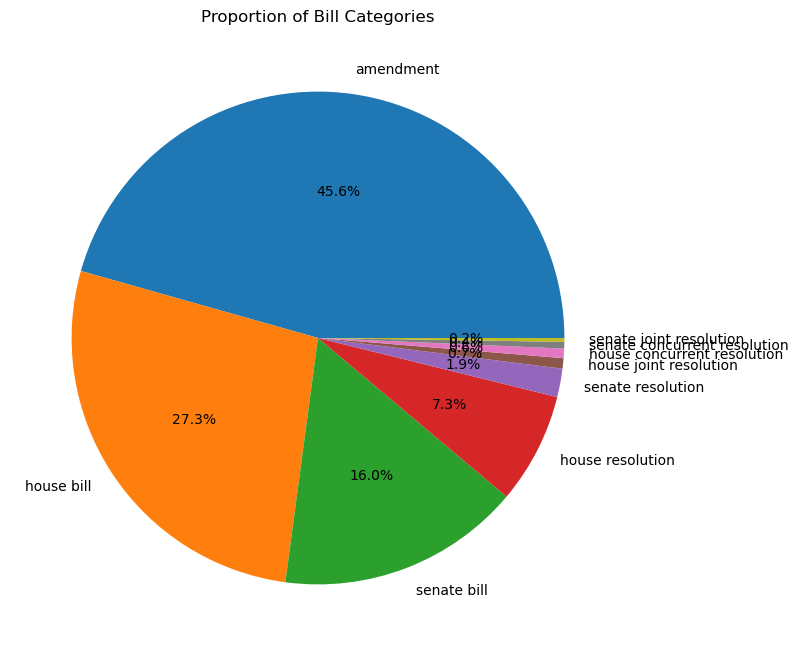

In [6]:
category_pct = bills_actions.groupby("category").size()
category_pct = category_pct / category_pct.sum()
category_pct = category_pct.sort_values(ascending=False)
print(category_pct)

# Based on the output of the above code:
# Create a pie chart 

import matplotlib.pyplot as plt
category_pct.plot.pie(autopct='%1.1f%%', figsize=(8, 8), title='Proportion of Bill Categories')
plt.ylabel('')  # Hide the y-label for better aesthetics
plt.show()
# 45.6% of the bills are ammendemnts
# 27% are house bills
# ~16% are senate bills
 # ~7.3% are house resolutions
 # Less than 2% are senate resolutions
# House and senate joint/concurrent resoluations each make up less than 1% of the data.

main_action
house floor actions                              0.315609
house amendment offered                          0.257463
senate committee/subcommittee actions            0.134950
other house amendment actions                    0.104167
senate amendment proposed (on the floor)         0.088930
house committee/subcommittee actions             0.061567
reported to senate                               0.011194
senate committee report filed after reporting    0.010261
other senate amendment actions                   0.005597
resolving differences -- house actions           0.004353
senate floor actions                             0.004042
house discharge petition filed                   0.000933
resolving differences -- senate actions          0.000933
dtype: float64


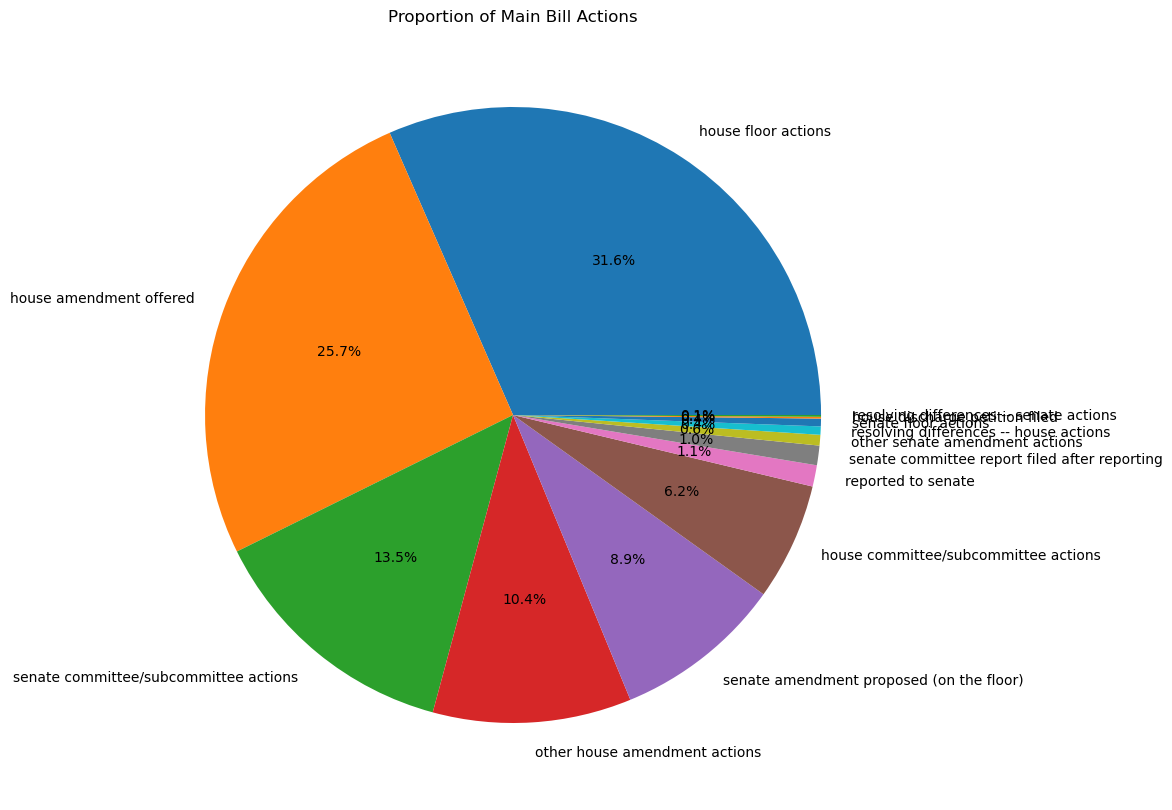

In [7]:
bills_actions
main_action_pct = bills_actions.groupby("main_action").size()
main_action_pct = main_action_pct / main_action_pct.sum()
main_action_pct = main_action_pct.sort_values(ascending=False)
print(main_action_pct)
bills_actions

# Based on the output of the above code:
# Create a pie chart
import matplotlib.pyplot as plt
main_action_pct.plot.pie(autopct='%1.1f%%', figsize=(10, 10), title='Proportion of Main Bill Actions')
plt.ylabel('')  # Hide the y-label for better aesthetics
plt.show()
# House floor actions comprise almost 32% of all bills
# House amendment offeres comprise just more than 1/4 of all bills
# Senate committee and subcommittee actions comprise 13% of the bills
# Other House amendment actions comprise 10% of the bills
# Senate amendmnents proposed on the floor comprise nearly 9% of the bills in the dataset.
# House Committee/Subcommittee actions comprise 6.1% of the bills
# "Reported to senate" makes up 1% of the bills
# Every other type comprises less than 1% of the bills

In [ ]:
# How many house floor actions are there as a part of senate bills (category)? Use a query
house_floor_senate_bills = bills_actions.query("main_action == 'house floor actions' and category == 'senate bill'")
house_floor_senate_bills 
print(house_floor_senate_bills.shape)  
 

#There are 116 house floor actions that are part of senate bills

(116, 8)


In [16]:
## Of the house floor actions, how many of them contain the word "suspends"?
suspended = house_floor_senate_bills["action"].str.contains("suspend", case=False, na=False)
print(suspended.sum())       # <-- number of rows containing "suspend"

# 80 house floor actions contain the word "suspend"

# After looking at the data, all bills containing the word "suspend" are to pass a bill, whether amended or not.
# So the percentage of house floor actions that contain the word "suspend" answers the question of how many actions were suspended.
suspend_pct = suspended.sum() / house_floor_senate_bills.shape[0]
print(f"Percentage of house floor actions that contain the word 'suspend': {suspend_pct:.1%}")

80
Percentage of house floor actions that contain the word 'suspend': 69.0%


In [17]:
amended = house_floor_senate_bills["action"].str.contains("amended", case=False, na=False)
print(amended.sum())         # <-- number of rows containing "amended"

# After looking at the data, all bills containing the word "amended" were identical in action,
# So summarizing the number of actions containing "amended" answers the question of how many actions were suspended as amended.

amended_pct = amended.sum() / house_floor_senate_bills.shape[0]
print(f"Percentage of house floor actions that contain the word 'amended': {amended_pct:.1%}")
# 18 house floor actions contain the word "amended"

18
Percentage of house floor actions that contain the word 'amended': 15.5%


In [ ]:
# Use regular expressions to extract the name of specific people (Mrs., Mr., Ms.)


# Extract names with Mr., Mrs., or Ms. and count total mentions
house_floor_counts = (
    house_floor_senate_bills["action"]
    # 1️ Find all patterns like "Mr. Smith" or "Ms. Johnson"
    .str.findall(r"(?:Mr\.|Mrs\.|Ms\.)\s+[A-Z][a-z]+(?:\s[A-Z][a-z]+)?")
    # 2️ Expand lists of names into individual rows
    .explode()
    # 3 Drop rows with no matches
    .dropna()
    # 4 Count each unique name
    .value_counts()
    # 5 Convert to a DataFrame
    .reset_index()
)

# Rename columns for clarity
house_floor_counts.columns = ["person", "count"]

# Display top 10 most-mentioned people
print(house_floor_counts.head(10))



         person  count
0    Mr. Takano      9
1  Mrs. Dingell      6
2   Ms. Haaland      6
3      Mr. Case      5
4      Ms. Bass      5
5     Ms. Kelly      5
6   Mr. Pallone      5
7    Ms. Norton      4
8        Mr. De      4
9   Mr. Huffman      4


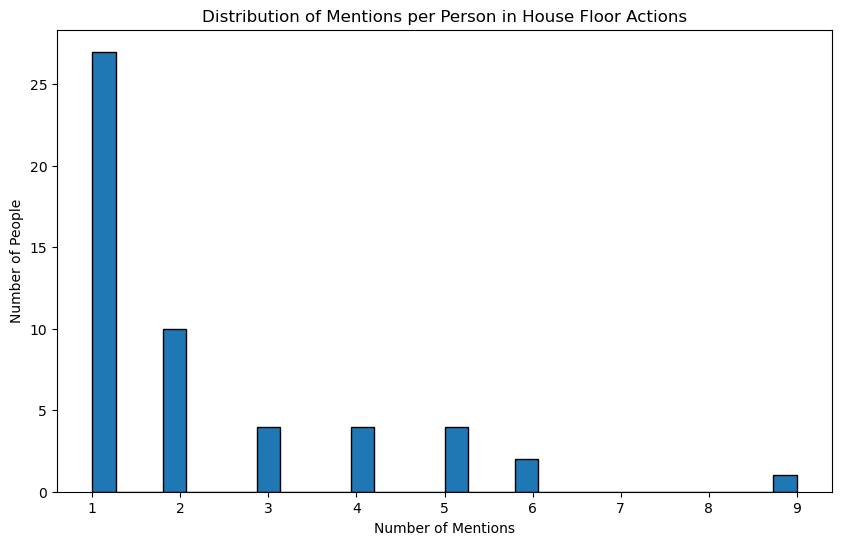

In [22]:
# Distruibution of mentions per person
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(house_floor_counts["count"], bins=30, edgecolor="k")
plt.xlabel("Number of Mentions")
plt.ylabel("Number of People")
plt.title("Distribution of Mentions per Person in House Floor Actions")
plt.show()

In [ ]:
# subset the bills_actions data to only include senate amendment proposed on the floor
onthe_floor_actions = bills_actions[bills_actions["main_action"] == "senate amendment proposed (on the floor)"]
onthe_floor_actions

In [25]:
import pandas as pd
import itertools
import re

TEXT_COL = "action"  # adjust if your text column is named differently

# Regex that matches Senator/Mr./Ms./Mrs. + Name (handles hyphens/apostrophes and two-word surnames)
REGEX = r"(?:Senator|Sen\.|Mr\.|Mrs\.|Ms\.)\s+[A-Z][a-zA-Z'.-]+(?:\s[A-Z][a-zA-Z'.-]+)?"

tmp = onthe_floor_actions.copy()

# --- Build a bill key (congress-bill_type-bill_number if present; otherwise fall back) ---
if {"congress", "bill_type", "bill_number"}.issubset(tmp.columns):
    tmp["bill_key"] = (
        tmp["congress"].astype(str) + "-" +
        tmp["bill_type"].astype(str) + "-" +
        tmp["bill_number"].astype(str)
    )
elif {"bill_type", "bill_number"}.issubset(tmp.columns):
    tmp["bill_key"] = tmp["bill_type"].astype(str) + "-" + tmp["bill_number"].astype(str)
else:
    tmp = tmp.reset_index().rename(columns={"index": "bill_key"})

# --- Extract all name mentions per row ---
tmp["mentions_row"] = tmp[TEXT_COL].str.findall(REGEX)

# --- Aggregate to bill level: flatten mentions from all actions within each bill ---
by_bill = (
    tmp.groupby("bill_key", as_index=False)
      .agg(
          all_mentions=("mentions_row", lambda s: list(itertools.chain.from_iterable(s))),
          n_actions=(TEXT_COL, "count")   # just FYI: how many actions per bill
      )
)

# --- Get ordered unique names per bill (keeps first-seen order across actions) ---
def ordered_unique(seq):
    seen, out = set(), []
    for x in seq:
        if x not in seen:
            seen.add(x)
            out.append(x)
    return out

by_bill["unique_mentions"] = by_bill["all_mentions"].apply(ordered_unique)

# --- Count senators per bill (use distinct people) ---
by_bill["n_senators"] = by_bill["unique_mentions"].str.len()

# --- First two unique mentions: Senator 1 and Senator 2 ---
by_bill["senator_1"] = by_bill["unique_mentions"].str[0]
by_bill["senator_2"] = by_bill["unique_mentions"].str[1]

# --- Final per-bill dataset you need ---
senators_per_bill = by_bill[["bill_key", "n_senators", "senator_1", "senator_2", "unique_mentions", "n_actions"]].copy()

# --- Distribution of number of senators per bill ---
distribution = senators_per_bill["n_senators"].value_counts().sort_index()
print("Distribution of # senators per bill:\n", distribution)

# --- Coauthor question: for each Senator 1, how many distinct Senator 2s? ---
coauthor_counts = (
    senators_per_bill
    .dropna(subset=["senator_1", "senator_2"])
    .groupby("senator_1")["senator_2"]
    .nunique()
    .reset_index(name="n_distinct_senator2")
    .sort_values("n_distinct_senator2", ascending=False)
)

print("\nTop Senator 1 coauthor counts:\n", coauthor_counts.head(10))


Distribution of # senators per bill:
 n_senators
1     20
2     97
3      5
4      4
5      1
6      1
7      1
30     1
40     1
Name: count, dtype: int64

Top Senator 1 coauthor counts:
             senator_1  n_distinct_senator2
10  Senator McConnell                   40
1      Senator Cornyn                    9
13  Senator Murkowski                    6
0       Senator Braun                    5
12      Senator Moran                    4
18      Senator Sasse                    3
24      Senator Thune                    3
4     Senator Fischer                    2
2      Senator Cramer                    2
17      Senator Rubio                    2


C:\Users\jland\AppData\Local\Temp\ipykernel_10872\1245841674.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=senators_per_bill, x="n_senators", palette="viridis")


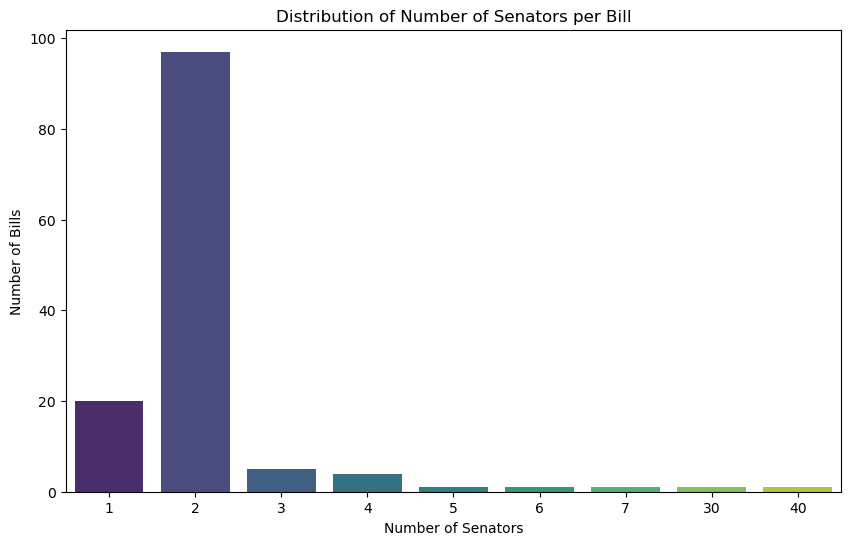

In [27]:
senators_per_bill

# Distribution of number of senators per bill
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(data=senators_per_bill, x="n_senators", palette="viridis")
plt.xlabel("Number of Senators")
plt.ylabel("Number of Bills")
plt.title("Distribution of Number of Senators per Bill")
plt.show()

In [ ]:
# Insights

# Collaboration seems to be a pertient feature of the senate-- to a certain extent. The vast majority of bills are authored by two senators. However, the 2nd high share of n_senators is just 1.
# Bills with 3 or more senators are quite rare, as are the two outlier bills with 30 and 40 senators registered as co-authors. 
# Senator McConnell has the highest number of distinct co-authors with 40 different senators. This may be due to his long tenure in the senate and his role as Senate Minority Leader.
# No other senator has 10 or more distinct co-authors, suggesting the McConnell may influence how much collaboration seems to be going on in the senate.
# The 116th Congress convened from January of 2019 to January of 2021, meaning the COVID pandemic may have affected the frequency in which bills were introduced, suspeended, amended, and co-authored.


array([ 2,  1,  3,  4, 40,  5, 30,  6,  7])